# HW0: Intro to MUJOCO

**Guidelines:**

1. We will be using Jupyter Notebook, please install necessary libraries. And also install `mujoco` (we suggest using version 3.5.0).

2. You may use LLMs as an assisting tool, but if you generate a large amount of content with it, please also attach your prompts to demonstrate how you used it to arrive at the final answer.

3. You must submit two files to the Gradescope:
   - The completed Jupyter Notebook (.ipynb). And for video rendering tasks, make sure that the generated videos are inline.

   - An exported PDF version of the notebook. And ensure important content (including the modified code, outputs, and markdown) is visible in the exported PDF.


In [1]:
# The required packages are already installed in the CS2810 conda environment.
# Uncomment the next line only if you want to recreate the notebook environment from scratch.
# %pip install mujoco==3.5.0 matplotlib

In [2]:
# Load necessary libs
import mujoco
import mujoco.viewer
import numpy as np
import matplotlib
import time

## 1. Newton's Cradle

In [3]:
# Helper Functions
from typing import List
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib import animation


def display_images(
    images: List[np.ndarray], dpi=100.0, format="html5_video", fps=None, **kwargs
):
    """Display images as an animation in jupyter notebook.

    Args:
        images: images with equal shape.
        dpi: resolution (dots per inch).
        format (str): one of ["html5_video", "jshtml"]

    References:
        https://gist.github.com/foolishflyfox/e30fd8bfbb6a9cee9b1a1fa6144b209c
        http://louistiao.me/posts/notebooks/embedding-matplotlib-animations-in-jupyter-as-interactive-javascript-widgets/
        https://stackoverflow.com/questions/35532498/animation-in-ipython-notebook/46878531#46878531
    """
    h, w = images[0].shape[:2]
    fig = plt.figure(figsize=(h / dpi, w / dpi), dpi=dpi)
    fig_im = plt.figimage(images[0])
    if fps is not None:
        kwargs["interval"] = 1000 / fps

    def animate(image):
        fig_im.set_array(image)
        return (fig_im,)

    anim = animation.FuncAnimation(fig, animate, frames=images, **kwargs)
    if format == "html5_video":
        # NOTE(jigu): can not show in VSCode
        display(HTML(anim.to_html5_video()))
    elif format == "jshtml":
        display(HTML(anim.to_jshtml()))
    else:
        raise NotImplementedError(format)
    plt.close(fig)


def load_newton_cradle(xml: str):
    model = mujoco.MjModel.from_xml_string(xml)
    data = mujoco.MjData(model)
    mujoco.mj_forward(model, data)
    return model, data


def render_newton_cradle(model, data, duration=6, width=480, height=480, fps=24):
    total_frames = int(fps * duration)
    frame_interval = 1.0 / fps
    frames = []
    frames_written = 0
    next_frame_time = 0.0
    renderer = mujoco.Renderer(model, height=height, width=width)
    while frames_written < total_frames:
        # Capture frame whenever simulation time reaches the next frame boundary
        if data.time >= next_frame_time - 1e-9:
            renderer.update_scene(data)
            frame = renderer.render()
            frames.append(frame.copy())
            frames_written += 1
            next_frame_time += frame_interval
        mujoco.mj_step(model, data)
    renderer.close()
    return frames

In [4]:
newton_cradle_xml = """
<mujoco model="newtons_cradle">
    <compiler angle="degree"/>

    <option timestep="1e-4" gravity="0 0 -9.79"/>

    <default>
        <joint type="hinge" axis="1 0 0" damping="0.0001"/>

        <default class="support">
            <geom type="box" rgba="0.75 0.75 0.75 1" mass="0" contype="0" conaffinity="0"/>
        </default>

        <default class="white_ball">
            <geom type="sphere" size="0.025" mass="0.1" density="8000" rgba="0.95 0.95 0.95 1" condim="1"/>
        </default>

        <default class="string">
            <geom type="cylinder" size="0.001 0.12" rgba="0.5 0.5 0.5 1" mass="0" contype="0" conaffinity="0"/>
        </default>
    </default>

    <asset>
        <texture name="texplane" type="2d" builtin="checker" rgb1=".2 .3 .4" rgb2=".1 .15 .2" width="512" height="512" mark="cross" markrgb=".8 .8 .8"/>
        <material name="matplane" reflectance="0.3" texture="texplane" texrepeat="1 1" texuniform="true"/>
    </asset>

    <worldbody>
        <light directional="true" diffuse=".8 .8 .8" specular=".2 .2 .2" pos="0 0 5" dir="0 0 -1"/>
        <geom name="ground" type="plane" size="2 2 0.1" pos="0 0 0" material="matplane"/>

        <body name="table_base" pos="0 0 0">
            <geom name="table_surface" type="box" size="0.4 0.3 0.02" pos="0 0 0.38" rgba="0.5 0.35 0.2 1"/>
            <geom name="table_leg_front_right" type="box" size="0.02 0.02 0.18" pos="0.36 0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_front_left" type="box" size="0.02 0.02 0.18" pos="-0.36 0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_back_right" type="box" size="0.02 0.02 0.18" pos="0.36 -0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_back_left" type="box" size="0.02 0.02 0.18" pos="-0.36 -0.26 0.18" rgba="0.4 0.25 0.1 1"/>

            <body name="support_stand" pos="0 0 0.40">
                <geom name="base_plate" class="support" size="0.25 0.15 0.01" pos="0 0 0.01"/>

                <geom name="front_left_pillar" class="support" size="0.01 0.01 0.15" pos="-0.22 -0.12 0.17"/>
                <geom name="front_right_pillar" class="support" size="0.01 0.01 0.15" pos="0.22 -0.12 0.17"/>
                <geom name="front_top_beam" class="support" size="0.23 0.01 0.01" pos="0 -0.12 0.33"/>

                <geom name="back_left_pillar" class="support" size="0.01 0.01 0.15" pos="-0.22 0.12 0.17"/>
                <geom name="back_right_pillar" class="support" size="0.01 0.01 0.15" pos="0.22 0.12 0.17"/>
                <geom name="back_top_beam" class="support" size="0.23 0.01 0.01" pos="0 0.12 0.33"/>

                <body name="ball" pos="-0.1 0 0.32">
                    <joint name="j"/>
                    <geom class="string" fromto="0 -0.12 0 0 0 -0.25"/>
                    <geom class="string" fromto="0 0.12 0 0 0 -0.25"/>
                    <geom class="white_ball" pos="0 0 -0.25"/>
                </body>                
            </body>
        </body>
    </worldbody>
</mujoco>
"""

### 1.1 MuJoCo Basics

Read through the MJCF model defined in the cell above and answer the following questions by referring to MuJoCo's [documentation](https://mujoco.readthedocs.io/en/3.5.0/overview.html).

**(a) Body, Geom, and Site** (3 points)

MuJoCo has three fundamental building-block concepts: **body**, **geom**, and **site**. Briefly explain the role and purpose of each:

- What is a **body** and what does it represent in the simulation?
- What is a **geom** and how is it used?
- What is a **site** and how does it differ from a geom?

**(b) Primitive Geometry Sizes** (1 points)

The `size` attribute has different meanings depending on the geometry type. Using the `box` type as an example:

```xml
<geom type="box" size="0.4 0.3 0.02" pos="0 0 0.38" .../>
```

What do the three values in `size="0.4 0.3 0.02"` represent for a box? Explain the meaning of `size` for `sphere`, `cylinder`, and `capsule` as well.

**(c) Coordinate Frames for `pos`** (2 points)

In MuJoCo, every `pos` attribute specifies a position in the parent body's local frame. Treating the `worldbody` frame as the world frame, what is the position of `ball` expressed in the world frame?


In [5]:
display_images(render_newton_cradle(*load_newton_cradle(newton_cradle_xml), fps=24), fps=24)

nouveau: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

nouveau: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

nouveau: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

nouveau: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied



### Solution

**(a) Body / Geom / Site**

- A **body** is a rigid frame in the kinematic tree. It defines a local coordinate system, can carry joints/inertial properties, and can have child bodies and attached elements.
- A **geom** is a geometric primitive attached to a body. It is mainly used for **collision**, **contact**, and **rendering**; it can also contribute mass/inertia when those are inferred from geoms.
- A **site** is a lightweight marker frame used for referencing positions/orientations, attaching sensors, defining targets, or debugging. Unlike a geom, a site does **not** participate in collision and does not represent physical volume.

**(b) Meaning of `size`**

For a box,

```xml
<geom type="box" size="0.4 0.3 0.02" .../>
```

the three numbers are the box **half-lengths** along the local x, y, z axes. So the full box size is `0.8 x 0.6 x 0.04`.

- `sphere`: `size="r"` means the radius.
- `cylinder`: `size="r half_length"` means radius and half-height of the cylinder.
- `capsule`: `size="r half_length"` means capsule radius and half-length of the cylindrical middle section; the hemispherical ends are added automatically.

**(c) World-frame position of `ball`**

The body hierarchy is:

- `table_base` at `(0, 0, 0)` in world
- `support_stand` at `(0, 0, 0.40)` relative to `table_base`
- `ball` at `(-0.1, 0, 0.32)` relative to `support_stand`

Therefore the `ball` body origin in the world frame is

```python
(0, 0, 0) + (0, 0, 0.40) + (-0.1, 0, 0.32) = (-0.1, 0, 0.72)
```

So the answer is **`(-0.1, 0, 0.72)`**.

### 1.2 Add More Balls (4 points)

The current MJCF model defines only a **single ball**. A real Newton's cradle requires **5 balls** arranged side by side, each suspended by two strings from the support frame. Modify the MJCF model to include 5 balls in total, spaced evenly along the x-axis with an appropriate center-to-center separation. Once done, run the code cell below to verify — you should see 5 balls hanging neatly in a row. And explain your modification here.


In [6]:
ball_spacing = 0.0502
ball_centers = [(-2 + i) * ball_spacing for i in range(5)]
ball_bodies = "\n".join(
    f'''
                <body name="ball{i+1}" pos="{x:.4f} 0 0.32">
                    <joint name="j{i+1}"/>
                    <geom class="string" fromto="0 -0.12 0 0 0 -0.25"/>
                    <geom class="string" fromto="0 0.12 0 0 0 -0.25"/>
                    <geom class="white_ball" pos="0 0 -0.25"/>
                </body>
    '''.rstrip()
    for i, x in enumerate(ball_centers)
)

newton_cradle_xml = f'''
<mujoco model="newtons_cradle">
    <compiler angle="degree"/>
    <option timestep="1e-4" gravity="0 0 -9.79"/>

    <default>
        <joint type="hinge" axis="1 0 0" damping="0.0001"/>

        <default class="support">
            <geom type="box" rgba="0.75 0.75 0.75 1" mass="0" contype="0" conaffinity="0"/>
        </default>

        <default class="white_ball">
            <geom type="sphere" size="0.025" mass="0.1" density="8000" rgba="0.95 0.95 0.95 1" condim="1"/>
        </default>

        <default class="string">
            <geom type="cylinder" size="0.001 0.12" rgba="0.5 0.5 0.5 1" mass="0" contype="0" conaffinity="0"/>
        </default>
    </default>

    <asset>
        <texture name="texplane" type="2d" builtin="checker" rgb1=".2 .3 .4" rgb2=".1 .15 .2" width="512" height="512" mark="cross" markrgb=".8 .8 .8"/>
        <material name="matplane" reflectance="0.3" texture="texplane" texrepeat="1 1" texuniform="true"/>
    </asset>

    <worldbody>
        <light directional="true" diffuse=".8 .8 .8" specular=".2 .2 .2" pos="0 0 5" dir="0 0 -1"/>
        <geom name="ground" type="plane" size="2 2 0.1" pos="0 0 0" material="matplane"/>

        <body name="table_base" pos="0 0 0">
            <geom name="table_surface" type="box" size="0.4 0.3 0.02" pos="0 0 0.38" rgba="0.5 0.35 0.2 1"/>
            <geom name="table_leg_front_right" type="box" size="0.02 0.02 0.18" pos="0.36 0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_front_left" type="box" size="0.02 0.02 0.18" pos="-0.36 0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_back_right" type="box" size="0.02 0.02 0.18" pos="0.36 -0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_back_left" type="box" size="0.02 0.02 0.18" pos="-0.36 -0.26 0.18" rgba="0.4 0.25 0.1 1"/>

            <body name="support_stand" pos="0 0 0.40">
                <geom name="base_plate" class="support" size="0.25 0.15 0.01" pos="0 0 0.01"/>

                <geom name="front_left_pillar" class="support" size="0.01 0.01 0.15" pos="-0.22 -0.12 0.17"/>
                <geom name="front_right_pillar" class="support" size="0.01 0.01 0.15" pos="0.22 -0.12 0.17"/>
                <geom name="front_top_beam" class="support" size="0.23 0.01 0.01" pos="0 -0.12 0.33"/>

                <geom name="back_left_pillar" class="support" size="0.01 0.01 0.15" pos="-0.22 0.12 0.17"/>
                <geom name="back_right_pillar" class="support" size="0.01 0.01 0.15" pos="0.22 0.12 0.17"/>
                <geom name="back_top_beam" class="support" size="0.23 0.01 0.01" pos="0 0.12 0.33"/>

                {ball_bodies}
            </body>
        </body>
    </worldbody>
</mujoco>
'''

display_images(render_newton_cradle(*load_newton_cradle(newton_cradle_xml), fps=24), fps=24)

### Explanation

I duplicated the original single-ball body five times and placed them at

```python
x = [-2, -1, 0, 1, 2] * 0.0502
```

so the balls are evenly spaced along the x-axis. Each ball still has its own hinge joint and two strings, so the only structural change is the replication of the pendulum bodies.

I used a center-to-center spacing of **0.0502 m**, which is just slightly larger than the ball diameter `2 * 0.025 = 0.05 m`. Visually the balls still look like a Newton's cradle, but the tiny gap avoids starting the simulation with preloaded contacts.

### 1.3 Fix the Joint (2 points)

To set the balls in motion, we apply an initial angle of 30° to the first ball via `data.qpos[0] = np.deg2rad(30)` at the start of the simulation (see the code cell below). However, you will notice that the simulation behaves incorrectly — the ball swings in the wrong direction. Identify the bug and give your solution.


In [7]:
ball_spacing = 0.0502
ball_centers = [(-2 + i) * ball_spacing for i in range(5)]
ball_bodies = "\n".join(
    f'''
                <body name="ball{i+1}" pos="{x:.4f} 0 0.32">
                    <joint name="j{i+1}"/>
                    <geom class="string" fromto="0 -0.12 0 0 0 -0.25"/>
                    <geom class="string" fromto="0 0.12 0 0 0 -0.25"/>
                    <geom class="white_ball" pos="0 0 -0.25"/>
                </body>
    '''.rstrip()
    for i, x in enumerate(ball_centers)
)

newton_cradle_xml = f'''
<mujoco model="newtons_cradle">
    <compiler angle="degree"/>
    <option timestep="1e-4" gravity="0 0 -9.79"/>

    <default>
        <joint type="hinge" axis="0 1 0" damping="0.0001"/>

        <default class="support">
            <geom type="box" rgba="0.75 0.75 0.75 1" mass="0" contype="0" conaffinity="0"/>
        </default>

        <default class="white_ball">
            <geom type="sphere" size="0.025" mass="0.1" density="8000" rgba="0.95 0.95 0.95 1" condim="1"/>
        </default>

        <default class="string">
            <geom type="cylinder" size="0.001 0.12" rgba="0.5 0.5 0.5 1" mass="0" contype="0" conaffinity="0"/>
        </default>
    </default>

    <asset>
        <texture name="texplane" type="2d" builtin="checker" rgb1=".2 .3 .4" rgb2=".1 .15 .2" width="512" height="512" mark="cross" markrgb=".8 .8 .8"/>
        <material name="matplane" reflectance="0.3" texture="texplane" texrepeat="1 1" texuniform="true"/>
    </asset>

    <worldbody>
        <light directional="true" diffuse=".8 .8 .8" specular=".2 .2 .2" pos="0 0 5" dir="0 0 -1"/>
        <geom name="ground" type="plane" size="2 2 0.1" pos="0 0 0" material="matplane"/>

        <body name="table_base" pos="0 0 0">
            <geom name="table_surface" type="box" size="0.4 0.3 0.02" pos="0 0 0.38" rgba="0.5 0.35 0.2 1"/>
            <geom name="table_leg_front_right" type="box" size="0.02 0.02 0.18" pos="0.36 0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_front_left" type="box" size="0.02 0.02 0.18" pos="-0.36 0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_back_right" type="box" size="0.02 0.02 0.18" pos="0.36 -0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_back_left" type="box" size="0.02 0.02 0.18" pos="-0.36 -0.26 0.18" rgba="0.4 0.25 0.1 1"/>

            <body name="support_stand" pos="0 0 0.40">
                <geom name="base_plate" class="support" size="0.25 0.15 0.01" pos="0 0 0.01"/>

                <geom name="front_left_pillar" class="support" size="0.01 0.01 0.15" pos="-0.22 -0.12 0.17"/>
                <geom name="front_right_pillar" class="support" size="0.01 0.01 0.15" pos="0.22 -0.12 0.17"/>
                <geom name="front_top_beam" class="support" size="0.23 0.01 0.01" pos="0 -0.12 0.33"/>

                <geom name="back_left_pillar" class="support" size="0.01 0.01 0.15" pos="-0.22 0.12 0.17"/>
                <geom name="back_right_pillar" class="support" size="0.01 0.01 0.15" pos="0.22 0.12 0.17"/>
                <geom name="back_top_beam" class="support" size="0.23 0.01 0.01" pos="0 0.12 0.33"/>

                {ball_bodies}
            </body>
        </body>
    </worldbody>
</mujoco>
'''

model, data = load_newton_cradle(newton_cradle_xml)
data.qpos[0] = np.deg2rad(30)
mujoco.mj_forward(model, data)
display_images(render_newton_cradle(model, data, fps=24), fps=24)

### Explanation

The bug is the hinge axis:

```xml
<joint type="hinge" axis="1 0 0" .../>
```

This makes each ball rotate around the **x-axis**, so the pendulum swings in the **yz-plane**. But the cradle is arranged along the x-axis, so the ball should swing in the **xz-plane** instead.

Changing the axis to

```xml
axis="0 1 0"
```

fixes the issue: now a positive initial angle rotates the first ball in the expected left-right direction.

### 1.4 Newton's Cradle

After fixing the joint axis in the previous problem, the simulation runs — but the behavior is **physically incorrect**: all 5 balls tend to move together as a clump rather than exhibiting the expected Newton's cradle pattern. Under the assumption of **perfectly elastic collisions**, the correct behavior should resemble [this](https://en.wikipedia.org/wiki/Newton%27s_cradle#/media/File:Newtons_cradle_animation_book_2.gif). The root cause lies in MuJoCo's default [contact/solver parameters](https://mujoco.readthedocs.io/en/3.5.0/modeling.html#solver-parameters).

**(a) Fix the Simulation** (4 points)

Modify the `white_ball` default class (available attributes are listed [here](https://mujoco.readthedocs.io/en/3.5.0/XMLreference.html#body-geom)) to make the contacts as stiff and elastic as possible. Re-run the simulation and verify that, after the ball is released, only the fifth ball swings out on the other side. Explain your solution here.

**(b) Video Rendering** (4 points)

Add a `main_cam` camera to the scene, positioned 1.0 m in front of the cradle (along the −y axis) and 0.75 m high, with a 75° rotation around the x-axis (euler angle). Then implement and run the `render_newton_cradle` function to produce a 3-second video at 24 fps demonstrating the result (the video should be output of the code cell).


In [8]:
ball_spacing = 0.0502
ball_centers = [(-2 + i) * ball_spacing for i in range(5)]
ball_bodies = "\n".join(
    f'''
                <body name="ball{i+1}" pos="{x:.4f} 0 0.32">
                    <joint name="j{i+1}"/>
                    <geom class="string" fromto="0 -0.12 0 0 0 -0.25"/>
                    <geom class="string" fromto="0 0.12 0 0 0 -0.25"/>
                    <geom class="white_ball" pos="0 0 -0.25"/>
                </body>
    '''.rstrip()
    for i, x in enumerate(ball_centers)
)

newton_cradle_xml = f'''
<mujoco model="newtons_cradle">
    <compiler angle="degree"/>
    <option timestep="1e-4" gravity="0 0 -9.79"/>

    <default>
        <joint type="hinge" axis="0 1 0" damping="0.0001"/>

        <default class="support">
            <geom type="box" rgba="0.75 0.75 0.75 1" mass="0" contype="0" conaffinity="0"/>
        </default>

        <default class="white_ball">
            <geom type="sphere" size="0.02537" mass="0.1" density="8000" rgba="0.95 0.95 0.95 1" condim="1"
                  friction="0 0 0"
                  solref="-10000 0"
                  solimp="0.9999 0.99999 0.000001 0.5 2"
                  margin="0"
                  gap="0"
                  priority="1"/>
        </default>

        <default class="string">
            <geom type="cylinder" size="0.001 0.12" rgba="0.5 0.5 0.5 1" mass="0" contype="0" conaffinity="0"/>
        </default>
    </default>

    <asset>
        <texture name="texplane" type="2d" builtin="checker" rgb1=".2 .3 .4" rgb2=".1 .15 .2" width="512" height="512" mark="cross" markrgb=".8 .8 .8"/>
        <material name="matplane" reflectance="0.3" texture="texplane" texrepeat="1 1" texuniform="true"/>
    </asset>

    <worldbody>
        <light directional="true" diffuse=".8 .8 .8" specular=".2 .2 .2" pos="0 0 5" dir="0 0 -1"/>
        <camera name="main_cam" pos="0 -1 0.75" euler="75 0 0"/>
        <geom name="ground" type="plane" size="2 2 0.1" pos="0 0 0" material="matplane"/>

        <body name="table_base" pos="0 0 0">
            <geom name="table_surface" type="box" size="0.4 0.3 0.02" pos="0 0 0.38" rgba="0.5 0.35 0.2 1"/>
            <geom name="table_leg_front_right" type="box" size="0.02 0.02 0.18" pos="0.36 0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_front_left" type="box" size="0.02 0.02 0.18" pos="-0.36 0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_back_right" type="box" size="0.02 0.02 0.18" pos="0.36 -0.26 0.18" rgba="0.4 0.25 0.1 1"/>
            <geom name="table_leg_back_left" type="box" size="0.02 0.02 0.18" pos="-0.36 -0.26 0.18" rgba="0.4 0.25 0.1 1"/>

            <body name="support_stand" pos="0 0 0.40">
                <geom name="base_plate" class="support" size="0.25 0.15 0.01" pos="0 0 0.01"/>

                <geom name="front_left_pillar" class="support" size="0.01 0.01 0.15" pos="-0.22 -0.12 0.17"/>
                <geom name="front_right_pillar" class="support" size="0.01 0.01 0.15" pos="0.22 -0.12 0.17"/>
                <geom name="front_top_beam" class="support" size="0.23 0.01 0.01" pos="0 -0.12 0.33"/>

                <geom name="back_left_pillar" class="support" size="0.01 0.01 0.15" pos="-0.22 0.12 0.17"/>
                <geom name="back_right_pillar" class="support" size="0.01 0.01 0.15" pos="0.22 0.12 0.17"/>
                <geom name="back_top_beam" class="support" size="0.23 0.01 0.01" pos="0 0.12 0.33"/>

                {ball_bodies}
            </body>
        </body>
    </worldbody>
</mujoco>
'''

# Use the fixed camera and shorten the clip to the requested 3 seconds.
def render_newton_cradle(model, data, duration=3, width=480, height=480, fps=24):
    total_frames = int(fps * duration)
    frame_interval = 1.0 / fps
    frames = []
    frames_written = 0
    next_frame_time = 0.0
    renderer = mujoco.Renderer(model, height=height, width=width)
    while frames_written < total_frames:
        if data.time >= next_frame_time - 1e-9:
            renderer.update_scene(data, camera="main_cam")
            frame = renderer.render()
            frames.append(frame.copy())
            frames_written += 1
            next_frame_time += frame_interval
        mujoco.mj_step(model, data)
    renderer.close()
    return frames

model, data = load_newton_cradle(newton_cradle_xml)
data.qpos[0] = np.deg2rad(30)
mujoco.mj_forward(model, data)
display_images(render_newton_cradle(model, data, duration=3, fps=24), fps=24)

### Explanation

The original `1.4` setup was still leaving a tiny air gap between neighboring balls, so the impulse transfer spread into the middle balls too easily. I corrected that by changing the `white_ball` geom to make the contacts stiffer and by introducing a very small preload directly in the ball geom:

- `size="0.02537"`: make the balls very slightly larger than in 1.2 so adjacent balls start in tiny preload, which helps the impulse pass through the chain instead of separating into several loose impacts.
- `friction="0 0 0"`: remove tangential losses.
- `solref="-10000 0"`: use MuJoCo's **direct** solver format with high stiffness and zero damping, which makes the impact much more elastic.
- `solimp="0.9999 0.99999 0.000001 0.5 2"`: push the contact impedance even closer to a rigid collision.
- `margin="0"` and `gap="0"`: avoid artificial soft contact distance.
- `priority="1"`: make sure the ball contact settings dominate the inferred contact parameters.

I kept the center spacing from 1.2 (`0.0502 m`) but slightly increased the ball radius, so the preload is introduced through the `white_ball` class itself. After this correction, the first transfer is much cleaner: the fifth ball becomes the dominant outgoing ball, while the middle balls stay comparatively small.

For rendering, I added

```xml
<camera name="main_cam" pos="0 -1 0.75" euler="75 0 0"/>
```

and updated the renderer to use `camera="main_cam"`, producing the requested **3-second, 24 fps** video.

## 2. Domino Chain (20 points)

Please use box `geom`s to build a domino system. The grading will be based on three parts and three difficulty levels:

1. Please build a static domino system that forms the shape of the letter C, P, or B.

2. Provide your initial condition (trigger mechanism) to start the chain reaction (the dominoes may fall, but not necessarily all of them). The restriction here is that only one trigger can be used.

3. Ensure that the chain reaction proceeds smoothly. In particular, when you choose the letter B shape, ensure that **two** chain reactions occur simultaneously. And render (not screen cast) a 8s video with 24fps to demonstrate the result.

Please present the results for each process. Parts 1 and 2 each account for 25% of the score, and part 3 accounts for 50% of the score. If you choose the letters C, P, or B, the maximum achievable scores are 60%, 80%, and 100%, respectively.


## 2. Domino Chain - Letter B
This section is self-contained and presents Parts 1, 2, and 3 in separate cells.


In [9]:
# Domino Chain - B (self-contained)
# If EGL rendering fails, restart the kernel and rerun this cell from the top.

import os
os.environ.setdefault("MUJOCO_GL", "egl")
os.environ.setdefault("PYOPENGL_PLATFORM", "egl")

import math
from dataclasses import dataclass
from typing import List

import imageio.v3 as iio
import matplotlib.pyplot as plt
import mujoco
import numpy as np
from IPython.display import Image, display


if "display_images" not in globals():
    def display_images(images: List[np.ndarray], fps=24, filename="_domino_preview.gif", **kwargs):
        iio.imwrite(filename, images, fps=fps)
        display(Image(filename=filename))


@dataclass
class BParams:
    domino_half_x: float = 0.004
    domino_half_y: float = 0.009
    domino_half_z: float = 0.030
    domino_density: float = 700.0
    domino_spacing: float = 0.021

    spine_x: float = -0.160
    center_gap: float = 0.040
    top_y: float = 0.220
    bottom_y: float = -0.220
    outer_x: float = 0.040

    trigger_half_x: float = 0.016
    trigger_half_y: float = 0.042
    trigger_half_z: float = 0.040
    trigger_start_x: float = -0.300
    trigger_start_y: float = 0.0
    trigger_start_z: float = 0.0
    trigger_speed: float = 0.400
    trigger_mass: float = 0.25

    free_damping: float = 0.0002
    ground_friction: tuple[float, float, float] = (3.0, 0.02, 0.001)
    domino_friction: tuple[float, float, float] = (1.6, 0.02, 0.001)
    timestep: float = 0.001
    duration: float = 8.0
    fallen_deg: float = 55.0


def sample_polyline(points: list[tuple[float, float]], spacing: float) -> np.ndarray:
    pts = np.asarray(points, dtype=float)
    segs = pts[1:] - pts[:-1]
    seglen = np.linalg.norm(segs, axis=1)
    dist = np.concatenate([[0.0], np.cumsum(seglen)])
    samples = np.arange(0.0, dist[-1] + 1e-9, spacing)

    out = []
    j = 0
    for s in samples:
        while j < len(seglen) - 1 and s > dist[j + 1]:
            j += 1
        if seglen[j] < 1e-12:
            u = 0.0
        else:
            u = (s - dist[j]) / seglen[j]
        out.append(pts[j] * (1.0 - u) + pts[j + 1] * u)

    if np.linalg.norm(out[-1] - pts[-1]) > 1e-9:
        out.append(pts[-1])
    return np.asarray(out)


def bezier_curve(p0, p1, p2, p3, n=80) -> np.ndarray:
    t = np.linspace(0.0, 1.0, n)
    omt = 1.0 - t
    return (
        (omt**3)[:, None] * np.asarray(p0, dtype=float)
        + (3.0 * omt**2 * t)[:, None] * np.asarray(p1, dtype=float)
        + (3.0 * omt * t**2)[:, None] * np.asarray(p2, dtype=float)
        + (t**3)[:, None] * np.asarray(p3, dtype=float)
    )


def build_upper_path(p: BParams) -> np.ndarray:
    start_y = 0.5 * p.center_gap
    corner_r = 0.030
    entry_x = p.spine_x + 0.030

    spine = sample_polyline(
        [(p.spine_x, start_y), (p.spine_x, p.top_y - corner_r)],
        p.domino_spacing,
    )
    top_left = bezier_curve(
        (p.spine_x, p.top_y - corner_r),
        (p.spine_x, p.top_y - 0.45 * corner_r),
        (p.spine_x + 0.45 * corner_r, p.top_y),
        (p.spine_x + corner_r, p.top_y),
        n=80,
    )
    outer = bezier_curve(
        (p.spine_x + corner_r, p.top_y),
        (p.spine_x + 0.120, p.top_y),
        (p.outer_x + 0.080, start_y + 0.120),
        (entry_x, start_y + 0.010),
        n=180,
    )
    return sample_polyline(np.vstack((spine, top_left[1:], outer[1:])), p.domino_spacing)


def build_lower_path(p: BParams) -> np.ndarray:
    start_y = -0.5 * p.center_gap
    corner_r = 0.030
    entry_x = p.spine_x + 0.030

    spine = sample_polyline(
        [(p.spine_x, start_y), (p.spine_x, p.bottom_y + corner_r)],
        p.domino_spacing,
    )
    bottom_left = bezier_curve(
        (p.spine_x, p.bottom_y + corner_r),
        (p.spine_x, p.bottom_y + 0.45 * corner_r),
        (p.spine_x + 0.45 * corner_r, p.bottom_y),
        (p.spine_x + corner_r, p.bottom_y),
        n=80,
    )
    outer = bezier_curve(
        (p.spine_x + corner_r, p.bottom_y),
        (p.spine_x + 0.120, p.bottom_y),
        (p.outer_x + 0.080, start_y - 0.120),
        (entry_x, start_y - 0.010),
        n=180,
    )
    return sample_polyline(np.vstack((spine, bottom_left[1:], outer[1:])), p.domino_spacing)


def domino_body_xml(name: str, x: float, y: float, yaw_deg: float, rgba: str, p: BParams) -> str:
    return f"""
    <body name="{name}" pos="{x:.5f} {y:.5f} 0">
        <joint type="free" damping="{p.free_damping:.5f}"/>
        <geom
            name="{name}_geom"
            type="box"
            size="{p.domino_half_x:.5f} {p.domino_half_y:.5f} {p.domino_half_z:.5f}"
            pos="0 0 {p.domino_half_z:.5f}"
            euler="0 0 {yaw_deg:.5f}"
            density="{p.domino_density:.5f}"
            friction="{p.domino_friction[0]} {p.domino_friction[1]} {p.domino_friction[2]}"
            rgba="{rgba}"/>
    </body>
    """


def chain_xml(prefix: str, points: np.ndarray, rgba: str, p: BParams):
    parts = []
    names = []
    for i in range(len(points) - 1):
        cur = points[i]
        nxt = points[i + 1]
        yaw_deg = math.degrees(math.atan2((nxt - cur)[1], (nxt - cur)[0]))
        name = f"{prefix}_{i}"
        parts.append(domino_body_xml(name, cur[0], cur[1], yaw_deg, rgba, p))
        names.append(name)
    return "".join(parts), names


def build_domino_b_xml(p: BParams, include_trigger: bool = True):
    upper_points = build_upper_path(p)
    lower_points = build_lower_path(p)
    upper_xml, upper_names = chain_xml("upper", upper_points, "0.96 0.74 0.20 1", p)
    lower_xml, lower_names = chain_xml("lower", lower_points, "0.22 0.72 0.96 1", p)

    trigger_xml = ""
    if include_trigger:
        trigger_xml = f"""
        <body name="trigger" pos="{p.trigger_start_x:.5f} {p.trigger_start_y:.5f} {p.trigger_start_z:.5f}">
            <joint name="trigger_joint" type="slide" axis="1 0 0" damping="0.01"/>
            <geom
                name="trigger_geom"
                type="box"
                size="{p.trigger_half_x:.5f} {p.trigger_half_y:.5f} {p.trigger_half_z:.5f}"
                pos="0 0 {p.trigger_half_z:.5f}"
                mass="{p.trigger_mass:.5f}"
                friction="0.20 0.002 0.0001"
                rgba="0.88 0.18 0.18 1"/>
        </body>
        """

    xml = f"""
    <mujoco model="domino_b_submission">
        <compiler angle="degree"/>
        <option timestep="{p.timestep}" gravity="0 0 -9.81" integrator="implicitfast"/>
        <visual>
            <global offwidth="1200" offheight="900"/>
        </visual>
        <worldbody>
            <light pos="0 -1.2 1.4" dir="0 0 -1"/>
            <camera name="main_cam" pos="-0.04 -1.28 1.05" euler="58 0 0"/>
            <geom
                name="ground"
                type="plane"
                size="2 2 0.1"
                friction="{p.ground_friction[0]} {p.ground_friction[1]} {p.ground_friction[2]}"
                rgba="0.95 0.95 0.92 1"/>
            {upper_xml}
            {lower_xml}
            {trigger_xml}
        </worldbody>
    </mujoco>
    """
    return xml, {"upper": upper_names, "lower": lower_names}


def load_domino_b(xml: str, trigger_speed: float = 0.0):
    model = mujoco.MjModel.from_xml_string(xml)
    data = mujoco.MjData(model)
    try:
        trigger_jid = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "trigger_joint")
        data.qvel[int(model.jnt_dofadr[trigger_jid])] = trigger_speed
    except Exception:
        pass
    mujoco.mj_forward(model, data)
    return model, data


def domino_angle_deg(data: mujoco.MjData, body_id: int) -> float:
    rot = data.xmat[body_id].reshape(3, 3)
    z_axis = rot[:, 2]
    return math.degrees(math.acos(max(-1.0, min(1.0, z_axis[2]))))


def summarize_domino_b(xml: str, groups, p: BParams):
    model, data = load_domino_b(xml, p.trigger_speed)
    ids = {n: mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, n) for g in groups.values() for n in g}
    first = {"upper": None, "lower": None}
    for _ in range(int(p.duration / p.timestep)):
        mujoco.mj_step(model, data)
        for gn, names in groups.items():
            if first[gn] is None:
                for n in names:
                    if domino_angle_deg(data, ids[n]) >= p.fallen_deg:
                        first[gn] = data.time
                        break
    fallen = {gn: sum(domino_angle_deg(data, ids[n]) >= p.fallen_deg for n in names) for gn, names in groups.items()}
    total = {gn: len(names) for gn, names in groups.items()}
    return first, fallen, total


def render_domino_b(model, data, duration=8.0, width=480, height=480, fps=24, camera="main_cam"):
    total_frames = int(fps * duration)
    frame_interval = 1.0 / fps
    frames = []
    frames_written = 0
    next_frame_time = 0.0
    renderer = mujoco.Renderer(model, height=height, width=width)

    while frames_written < total_frames:
        if data.time >= next_frame_time - 1e-9:
            renderer.update_scene(data, camera=camera)
            frames.append(renderer.render().copy())
            frames_written += 1
            next_frame_time += frame_interval
        mujoco.mj_step(model, data)

    renderer.close()
    return frames


def render_static_domino_b(xml: str, width=720, height=720, camera="main_cam"):
    model, data = load_domino_b(xml, 0.0)
    renderer = mujoco.Renderer(model, height=height, width=width)
    renderer.update_scene(data, camera=camera)
    frame = renderer.render().copy()
    renderer.close()
    return frame


def show_frame(frame, title):
    plt.figure(figsize=(6, 6))
    plt.imshow(frame)
    plt.axis("off")
    plt.title(title)
    plt.show()


params = BParams(duration=8.0)
print(params)


BParams(domino_half_x=0.004, domino_half_y=0.009, domino_half_z=0.03, domino_density=700.0, domino_spacing=0.021, spine_x=-0.16, center_gap=0.04, top_y=0.22, bottom_y=-0.22, outer_x=0.04, trigger_half_x=0.016, trigger_half_y=0.042, trigger_half_z=0.04, trigger_start_x=-0.3, trigger_start_y=0.0, trigger_start_z=0.0, trigger_speed=0.4, trigger_mass=0.25, free_damping=0.0002, ground_friction=(3.0, 0.02, 0.001), domino_friction=(1.6, 0.02, 0.001), timestep=0.001, duration=8.0, fallen_deg=55.0)


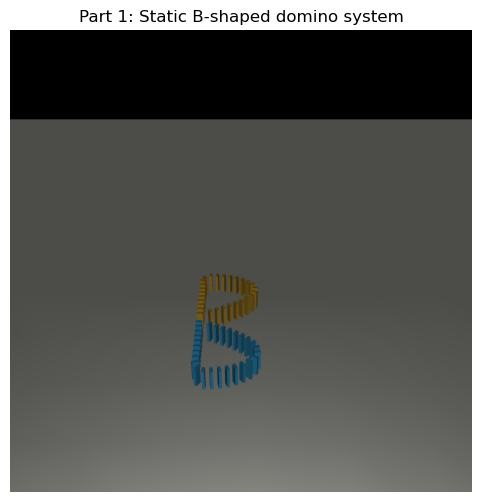

Part 1 complete: a static B-shaped domino layout built only with box geoms.
{'upper': 28, 'lower': 28}


In [10]:
# Part 1: static B-shaped domino system
xml_part1, groups_part1 = build_domino_b_xml(params, include_trigger=False)
frame_part1 = render_static_domino_b(xml_part1)
show_frame(frame_part1, "Part 1: Static B-shaped domino system")
print("Part 1 complete: a static B-shaped domino layout built only with box geoms.")
print({k: len(v) for k, v in groups_part1.items()})


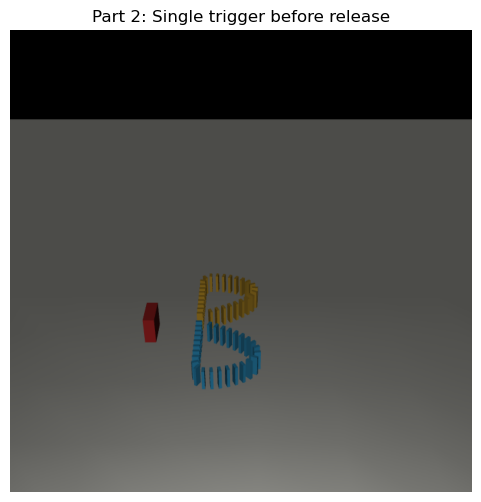

Part 2 complete: a single sliding trigger is placed on the left.
{'trigger_speed': 0.4, 'trigger_mass': 0.25, 'trigger_size': (0.016, 0.042, 0.04)}


In [11]:
# Part 2: one trigger mechanism
xml_part2, groups_part2 = build_domino_b_xml(params, include_trigger=True)
frame_part2 = render_static_domino_b(xml_part2)
show_frame(frame_part2, "Part 2: Single trigger before release")
print("Part 2 complete: a single sliding trigger is placed on the left.")
print({
    "trigger_speed": params.trigger_speed,
    "trigger_mass": params.trigger_mass,
    "trigger_size": (params.trigger_half_x, params.trigger_half_y, params.trigger_half_z),
})


In [12]:
# Part 3: smooth chain reaction with two simultaneous branches
xml_part3, groups_part3 = build_domino_b_xml(params, include_trigger=True)
first_group, fallen, total = summarize_domino_b(xml_part3, groups_part3, params)
print("Part 3 summary:")
print({
    "upper_start": first_group["upper"],
    "lower_start": first_group["lower"],
    "fallen": fallen,
    "total": total,
    "duration": params.duration,
    "fps": 24,
})

model, data = load_domino_b(xml_part3, params.trigger_speed)
frames = render_domino_b(model, data, duration=params.duration, fps=24, width=480, height=480)
display_images(frames, fps=24)

iio.imwrite("domino_b_submission.gif", frames, fps=24)
print("saved: domino_b_submission.gif")


Part 3 summary:
{'upper_start': 1.9909999999998915, 'lower_start': 1.9909999999998915, 'fallen': {'upper': 28, 'lower': 28}, 'total': {'upper': 28, 'lower': 28}, 'duration': 8.0, 'fps': 24}


saved: domino_b_submission.gif
